<a href="https://colab.research.google.com/github/Mitziq/G9-LATAM-Team-26/blob/main/01_Dataset_transaaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📊 Finance AI Asistente Inteligente de Salud Financiera

# 1. Generación del Dataset de Transacciones Financieras y perfil usuarios

## Este notebook genera un conjunto de datos sintético para entrenar un modelo de clasificación de transacciones financieras.

Las categorías utilizadas son:

- Alimentación
- Transporte
- Salud
- Vivienda
- Educación
- Servicios
- Entretenimiento/Ocio
- Suscripciones
- Gastos Hormiga
- Inversión/Ahorro
- Deudas
- Seguros
- Ropa
- Mascotas
- Otros

In [1]:
#Importando bibliotecas
import random
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

# =========================================================
# 1. CATÁLOGO DE COMERCIOS POR CATEGORÍA
# =========================================================
# Nota: "Starbucks" se quedó solo en Alimentación (ver GASTOS_HORMIGA_KEYWORDS
# más abajo para marcarlo como gasto hormiga sin duplicar categoría).
# "Mantenimiento" se quedó solo en Vivienda.

CATALOGO = {
    "Alimentación": [
        "Walmart", "Soriana", "Chedraui", "Bodega Aurrera", "Costco", "Sam's Club",
        "La Comer", "City Market", "Subway", "Domino's Pizza", "Little Caesars",
        "McDonald's", "Burger King", "Toks", "Vips", "El Globo", "Starbucks",
        "Italianni's", "Sushi Roll", "Chili's", "Mercado", "Despensa"
    ],
    "Transporte": [
        "Uber", "DiDi", "Cabify", "Gasolina Pemex", "Gasolina Shell", "Gasolina BP",
        "Caseta CAPUFE", "ADO", "ETN", "Viva Aerobus", "Aeroméxico",
        "Metro CDMX", "Metrobús"
    ],
    "Salud": [
        "Farmacias Guadalajara", "Farmacias del Ahorro", "Farmacia San Pablo",
        "Hospital Ángeles", "Hospital ABC", "Laboratorio Chopo", "Salud Digna",
        "Dentista", "Ópticas Devlyn", "Ginecólogo"
    ],
    "Vivienda": [
        "Renta", "Hipoteca", "Home Depot", "IKEA", "Mantenimiento",
        "Ferretería", "Pinturas Comex", "Construrama"
    ],
    "Educación": [
        "Coursera", "Platzi", "UNAM", "IPN", "Tec de Monterrey",
        "Compra Libros", "Amazon Libros", "Útiles", "Colegiatura"
    ],
    "Servicios": [
        "CFE", "Telmex", "Totalplay", "Izzi", "Megacable", "Gas Natural",
        "Servicio de Agua", "Telcel", "AT&T"
    ],
    "Entretenimiento": [
        "Cinépolis", "Cinemex", "Steam", "PlayStation Store", "Xbox Store",
        "Nintendo eShop", "Concierto", "Six Flags", "Museo"
    ],
    "Suscripciones": [
        "Netflix", "Spotify", "Disney+", "Amazon Prime", "Max",
        "YouTube Premium", "Google One", "Dropbox", "Apple Music", "Microsoft 365"
    ],
    "Inversión": [
        "CETES", "GBM", "Nu Ahorro", "AFORE", "Fondo Indexado",
        "ETF Vanguard", "Compra Acciones"
    ],

    "Deudas": [
        "Pago TDC BBVA", "Pago TDC Banamex", "Pago TDC Santander",
        "Pago Préstamo Personal", "Liverpool Crédito", "Pago Nómina Kueski"
    ],
    "Seguros": [
        "GNP Seguros", "AXA Seguros", "Seguros Monterrey", "Seguro Auto Qualitas"
    ],
    "Ropa": [
        "Liverpool", "Zara", "H&M", "C&A", "Palacio de Hierro", "Shein"
    ],
    "Mascotas": [
        "Petco", "Veterinario", "PatasPet"
    ],
    "Otros": [
        "Transferencia SPEI", "Compra Desconocida", "Cargo Varios", "OXXO", "7-Eleven"
    ],
}

# Comercios que, aunque pertenecen a una categoría "dueña", se consideran
# gasto hormiga (consumo pequeño y frecuente) — se marca como FLAG, no como
# categoría aparte, para no duplicar etiquetas.
GASTOS_HORMIGA_KEYWORDS = {
    "Starbucks", "Oxxo", "7-Eleven", "Café Punta del Cielo", "Coca-Cola",
    "Sabritas", "Pan Dulce", "Chocolate", "Galletas", "Helado"
}

# Rango de montos realistas por categoría (min, max) en MXN
RANGO_MONTOS = {
    "Alimentación": (60, 900),
    "Transporte": (30, 700),
    "Salud": (100, 3000),
    "Vivienda": (500, 12000),
    "Educación": (150, 5000),
    "Servicios": (150, 1200),
    "Entretenimiento": (80, 1200),
    "Suscripciones": (49, 299),
    "Inversión": (200, 5000),
    "Deudas": (300, 6000),
    "Seguros": (250, 3500),
    "Ropa": (200, 2500),
    "Mascotas": (100, 1500),
    "Otros": (20, 500),
}

FRECUENCIAS_AHORRO = ["Nula", "Baja", "Media", "Alta"]


# =========================================================
# 2. GENERAR TRANSACCIONES PARA UN USUARIO
# =========================================================
def generar_transacciones_usuario(n_transacciones):
    transacciones = []
    categorias = list(CATALOGO.keys())
    # pesos para que algunas categorías sean más frecuentes (más realista)
    pesos = [18, 12, 6, 5, 4, 10, 8, 8, 3, 6, 3, 6, 3, 8]

    for _ in range(n_transacciones):
        categoria = random.choices(categorias, weights=pesos, k=1)[0]
        comercio = random.choice(CATALOGO[categoria])
        min_monto, max_monto = RANGO_MONTOS[categoria]
        monto = round(np.random.uniform(min_monto, max_monto), 2)
        es_gasto_hormiga = comercio in GASTOS_HORMIGA_KEYWORDS

        transacciones.append({
            "descripcion": comercio,
            "valor": monto,
            "categoria": categoria,  # label para el clasificador de transacciones
            "es_gasto_hormiga": es_gasto_hormiga,
        })
    return transacciones


# =========================================================
# 3. REGLA DE NEGOCIO PARA ETIQUETAR EL PERFIL FINANCIERO
# =========================================================
def calcular_perfil_financiero(ingreso_mensual, nivel_endeudamiento,
                                frecuencia_ahorro, gasto_total):
    ratio_gasto = gasto_total / ingreso_mensual
    puntos_riesgo = 0

    if nivel_endeudamiento > 35:
        puntos_riesgo += 2
    elif nivel_endeudamiento > 18:
        puntos_riesgo += 1

    if ratio_gasto > 0.65:
        puntos_riesgo += 2
    elif ratio_gasto > 0.45:
        puntos_riesgo += 1

    if frecuencia_ahorro == "Nula":
        puntos_riesgo += 2
    elif frecuencia_ahorro == "Baja":
        puntos_riesgo += 1
    elif frecuencia_ahorro == "Alta":
        puntos_riesgo -= 1

    if puntos_riesgo >= 4:
        return "En riesgo"
    elif puntos_riesgo >= 2:
        return "En observación"
    else:
        return "Saludable"


# =========================================================
# 4. GENERA DATASET COMPLETO (varios usuarios)
# =========================================================
def generar_dataset(n_usuarios=300, min_trans=5, max_trans=25,
                     guardar_csv=True):
    filas_transacciones = []
    filas_usuarios = []

    for user_id in range(1, n_usuarios + 1):
        ingreso_mensual = round(np.random.uniform(6000, 60000), 2)
        nivel_endeudamiento = round(np.random.uniform(0, 80), 1)
        frecuencia_ahorro = random.choice(FRECUENCIAS_AHORRO)
        n_transacciones = random.randint(min_trans, max_trans)

        transacciones = generar_transacciones_usuario(n_transacciones)
        gasto_total = sum(t["valor"] for t in transacciones)

        perfil = calcular_perfil_financiero(
            ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, gasto_total
        )

        for t in transacciones:
            filas_transacciones.append({"user_id": user_id, **t})

        filas_usuarios.append({
            "user_id": user_id,
            "ingreso_mensual": ingreso_mensual,
            "nivel_endeudamiento": nivel_endeudamiento,
            "frecuencia_ahorro": frecuencia_ahorro,
            "gasto_total": round(gasto_total, 2),
            "perfil_financiero": perfil,
        })

    df_transacciones = pd.DataFrame(filas_transacciones)
    df_usuarios = pd.DataFrame(filas_usuarios)

    if guardar_csv:
        df_transacciones.to_csv("dataset_transacciones.csv", index=False)
        df_usuarios.to_csv("dataset_usuarios.csv", index=False)
        print("Archivos guardados: dataset_transacciones.csv, dataset_usuarios.csv")

    return df_transacciones, df_usuarios


# =========================================================
# 5. EJECUCIÓN DE EJEMPLO
# =========================================================
if __name__ == "__main__":
    df_transacciones, df_usuarios = generar_dataset(
        n_usuarios=4000, min_trans=4, max_trans=10
    )

    print("\n--- Transacciones (muestra) ---")
    print(df_transacciones.head())

    print("\n--- Usuarios (muestra) ---")
    print(df_usuarios.head())

    print("\nDistribución de perfiles financieros:")
    print(df_usuarios["perfil_financiero"].value_counts())

    print("\nDistribución de categorías de transacciones:")
    print(df_transacciones["categoria"].value_counts())

Archivos guardados: dataset_transacciones.csv, dataset_usuarios.csv

--- Transacciones (muestra) ---
   user_id       descripcion    valor     categoria  es_gasto_hormiga
0        1  Pago TDC Banamex  4472.37        Deudas             False
1        1        Metro CDMX   431.10    Transporte             False
2        1       Italianni's   191.06  Alimentación             False
3        1              Toks   191.04  Alimentación             False
4        2       City Market   564.94  Alimentación             False

--- Usuarios (muestra) ---
   user_id  ingreso_mensual  nivel_endeudamiento frecuencia_ahorro  \
0        1         26225.17                 76.1              Nula   
1        2          9136.52                 69.3              Nula   
2        3         50951.90                 17.0             Media   
3        4         30627.78                 62.8             Media   
4        5         58144.13                 64.7              Nula   

   gasto_total perfil_financie

#2. EDA (Exploración y limpieza)

INSPECCIÓN GENERAL

--- Usuarios: info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              4000 non-null   int64  
 1   ingreso_mensual      4000 non-null   float64
 2   nivel_endeudamiento  4000 non-null   float64
 3   frecuencia_ahorro    4000 non-null   object 
 4   gasto_total          4000 non-null   float64
 5   perfil_financiero    4000 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 187.6+ KB
None

--- Transacciones: info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28063 entries, 0 to 28062
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           28063 non-null  int64  
 1   descripcion       28063 non-null  object 
 2   valor             28063 non-null  float64
 3   categ

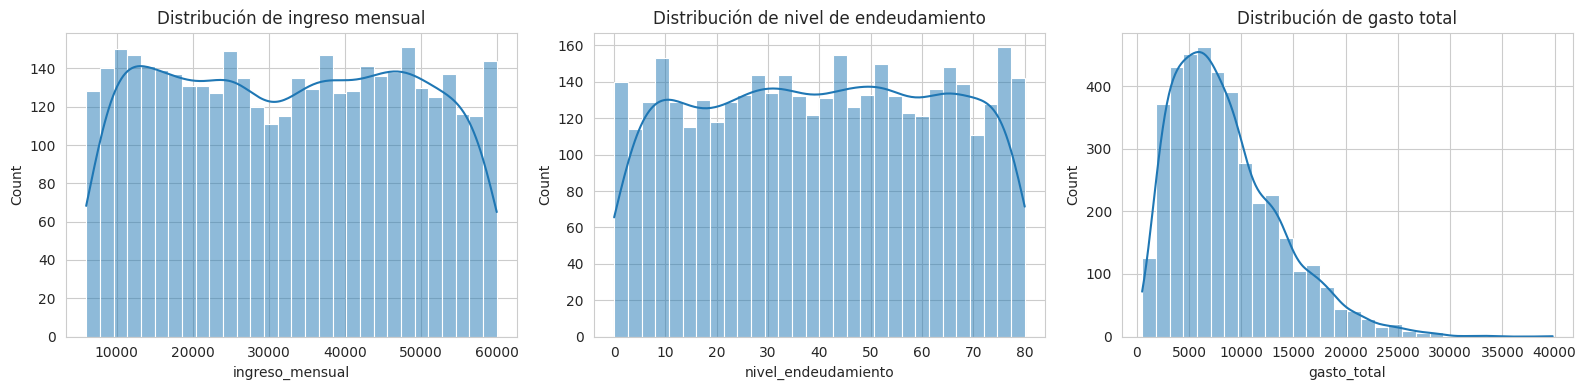


--- Detección de outliers (IQR) ---
ingreso_mensual: 0 outliers fuera de [-22377.4, 87610.6]
nivel_endeudamiento: 0 outliers fuera de [-38.9, 120.0]
gasto_total: 88 outliers fuera de [-5524.0, 21600.0]


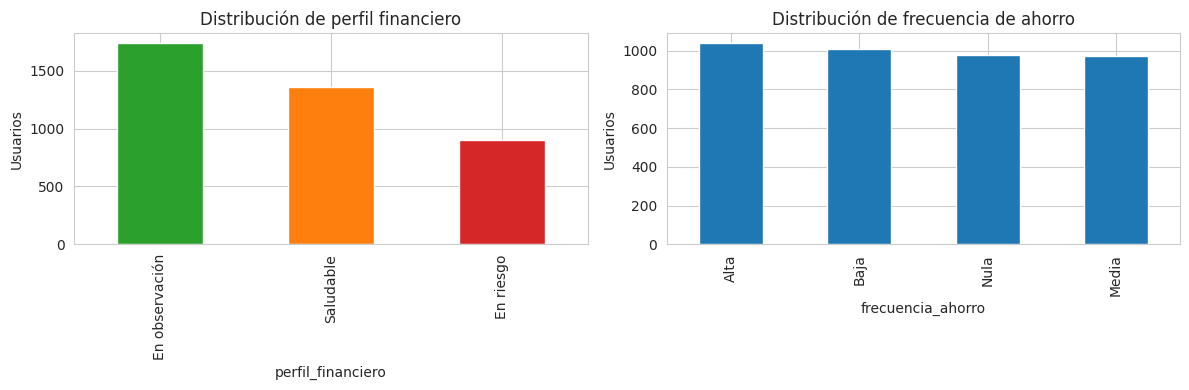


--- Perfil financiero vs. frecuencia de ahorro (%) ---
perfil_financiero  En observación  En riesgo  Saludable
frecuencia_ahorro                                      
Alta                         17.6        0.0       82.4
Baja                         65.7       18.3       16.0
Media                        57.3        7.7       34.9
Nula                         34.4       65.6        0.0

--- Gasto total y promedio por categoría ---
                 count         sum     mean
categoria                                  
Vivienda          1395  8746611.84  6269.97
Deudas            1685  5301871.24  3146.51
Educación         1151  2914538.70  2532.18
Salud             1725  2699430.90  1564.89
Alimentación      5098  2432271.03   477.10
Ropa              1700  2299098.69  1352.41
Inversión          814  2136263.38  2624.40
Servicios         2763  1845048.05   667.77
Seguros            815  1540617.96  1890.33
Entretenimiento   2250  1424220.60   632.99
Transporte        3353  1231738.66

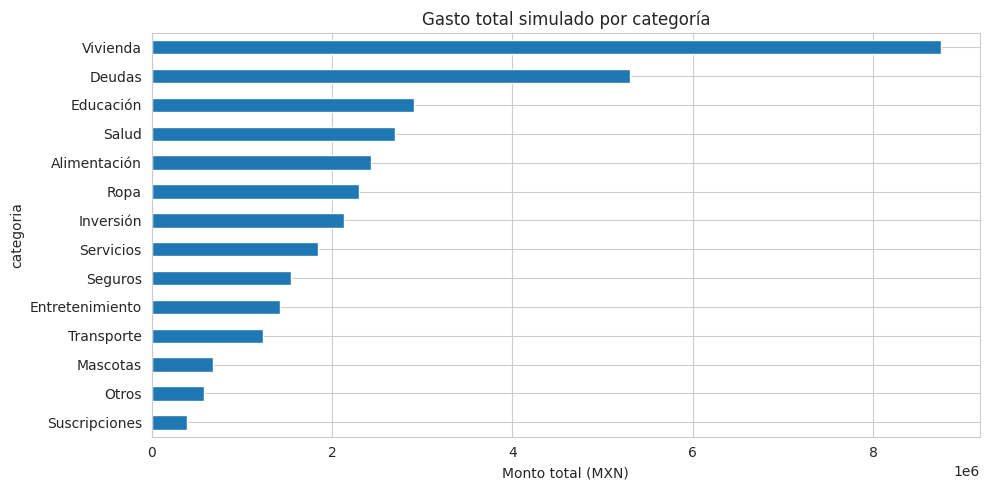


--- % de transacciones marcadas como gasto hormiga ---
es_gasto_hormiga
False    97.6
True      2.4
Name: proportion, dtype: float64


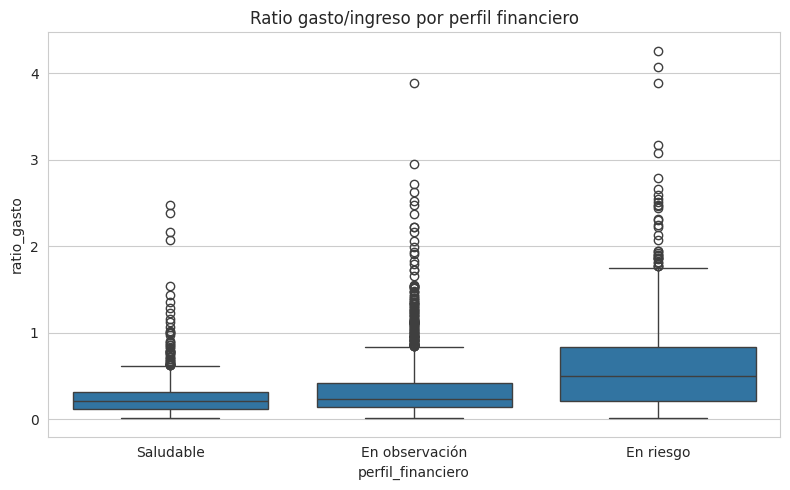

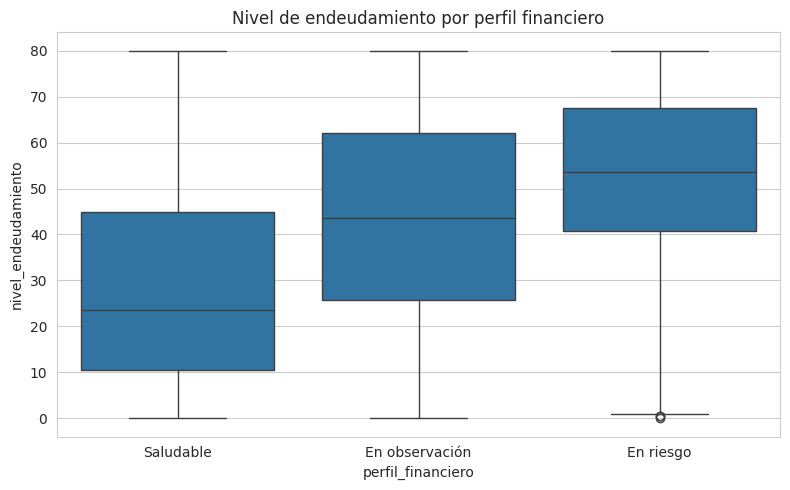


--- Matriz de correlación ---
                     ingreso_mensual  nivel_endeudamiento  gasto_total  \
ingreso_mensual                 1.00                 0.01        -0.02   
nivel_endeudamiento             0.01                 1.00        -0.02   
gasto_total                    -0.02                -0.02         1.00   
ratio_gasto                    -0.59                -0.01         0.60   

                     ratio_gasto  
ingreso_mensual            -0.59  
nivel_endeudamiento        -0.01  
gasto_total                 0.60  
ratio_gasto                 1.00  


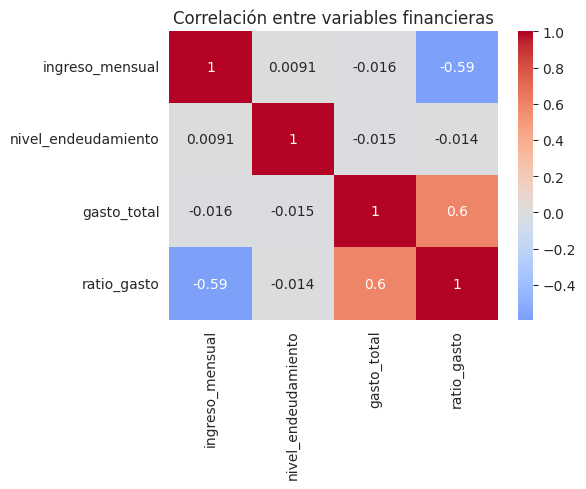


EDA completo. Gráficas guardadas como PNG en el directorio de trabajo.


In [2]:
"""
EDA
Requiere: dataset_usuarios.csv y dataset_transacciones.csv
          (generados con generar_dataset_financiero.py)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_usuarios = pd.read_csv("dataset_usuarios.csv")
df_transacciones = pd.read_csv("dataset_transacciones.csv")

# =========================================================
# 1. INSPECCIÓN GENERAL Y LIMPIEZA
# =========================================================
print("=" * 60)
print("INSPECCIÓN GENERAL")
print("=" * 60)

print("\n--- Usuarios: info ---")
print(df_usuarios.info())
print("\n--- Transacciones: info ---")
print(df_transacciones.info())

print("\n--- Valores nulos (usuarios) ---")
print(df_usuarios.isnull().sum())
print("\n--- Valores nulos (transacciones) ---")
print(df_transacciones.isnull().sum())

print("\n--- Duplicados exactos ---")
print("Usuarios:", df_usuarios.duplicated().sum())
print("Transacciones:", df_transacciones.duplicated().sum())

# Validaciones de rango (sanity checks financieros)
print("\n--- Validaciones de rango ---")
print("Ingresos <= 0:", (df_usuarios["ingreso_mensual"] <= 0).sum())
print("Endeudamiento fuera de [0,100]:",
      ((df_usuarios["nivel_endeudamiento"] < 0) |
       (df_usuarios["nivel_endeudamiento"] > 100)).sum())
print("Transacciones con valor <= 0:", (df_transacciones["valor"] <= 0).sum())


# =========================================================
# 2. DISTRIBUCIÓN DE VARIABLES NUMÉRICAS (usuarios)
# =========================================================
print("\n--- Estadísticas descriptivas (usuarios) ---")
print(df_usuarios[["ingreso_mensual", "nivel_endeudamiento", "gasto_total"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_usuarios["ingreso_mensual"], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Distribución de ingreso mensual")

sns.histplot(df_usuarios["nivel_endeudamiento"], bins=30, ax=axes[1], kde=True)
axes[1].set_title("Distribución de nivel de endeudamiento")

sns.histplot(df_usuarios["gasto_total"], bins=30, ax=axes[2], kde=True)
axes[2].set_title("Distribución de gasto total")
plt.tight_layout()
plt.savefig("eda_distribuciones_usuarios.png", dpi=100)
plt.show()

# Outliers vía IQR
print("\n--- Detección de outliers (IQR) ---")
for col in ["ingreso_mensual", "nivel_endeudamiento", "gasto_total"]:
    q1, q3 = df_usuarios[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_usuarios[col] < lim_inf) | (df_usuarios[col] > lim_sup)).sum()
    print(f"{col}: {n_outliers} outliers fuera de [{lim_inf:.1f}, {lim_sup:.1f}]")


# =========================================================
# 3. DISTRIBUCIÓN DEL PERFIL FINANCIERO Y FRECUENCIA DE AHORRO
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_usuarios["perfil_financiero"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#2ca02c", "#ff7f0e", "#d62728"]
)
axes[0].set_title("Distribución de perfil financiero")
axes[0].set_ylabel("Usuarios")

df_usuarios["frecuencia_ahorro"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Distribución de frecuencia de ahorro")
axes[1].set_ylabel("Usuarios")
plt.tight_layout()
plt.savefig("eda_perfil_ahorro.png", dpi=100)
plt.show()

# Cruce: perfil financiero vs frecuencia de ahorro (tabla de contingencia)
print("\n--- Perfil financiero vs. frecuencia de ahorro (%) ---")
tabla_cruzada = pd.crosstab(
    df_usuarios["frecuencia_ahorro"], df_usuarios["perfil_financiero"], normalize="index"
) * 100
print(tabla_cruzada.round(1))


# =========================================================
# 4. PATRONES DE CONSUMO (transacciones)
# =========================================================
print("\n--- Gasto total y promedio por categoría ---")
resumen_categoria = df_transacciones.groupby("categoria")["valor"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)
print(resumen_categoria.round(2))

plt.figure(figsize=(10, 5))
resumen_categoria["sum"].sort_values().plot(kind="barh")
plt.title("Gasto total simulado por categoría")
plt.xlabel("Monto total (MXN)")
plt.tight_layout()
plt.savefig("eda_gasto_por_categoria.png", dpi=100)
plt.show()

print("\n--- % de transacciones marcadas como gasto hormiga ---")
print(df_transacciones["es_gasto_hormiga"].value_counts(normalize=True).mul(100).round(1))


# =========================================================
# 5. RELACIÓN ENTRE VARIABLES Y PERFIL FINANCIERO
# =========================================================
# Ratio gasto/ingreso por perfil — para confirmar que la regla de negocio
# generó una separación razonable entre clases (importante antes de modelar)
df_usuarios["ratio_gasto"] = df_usuarios["gasto_total"] / df_usuarios["ingreso_mensual"]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_usuarios, x="perfil_financiero", y="ratio_gasto",
            order=["Saludable", "En observación", "En riesgo"])
plt.title("Ratio gasto/ingreso por perfil financiero")
plt.tight_layout()
plt.savefig("eda_ratio_gasto_por_perfil.png", dpi=100)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_usuarios, x="perfil_financiero", y="nivel_endeudamiento",
            order=["Saludable", "En observación", "En riesgo"])
plt.title("Nivel de endeudamiento por perfil financiero")
plt.tight_layout()
plt.savefig("eda_endeudamiento_por_perfil.png", dpi=100)
plt.show()

# Matriz de correlación de variables numéricas
print("\n--- Matriz de correlación ---")
corr = df_usuarios[["ingreso_mensual", "nivel_endeudamiento", "gasto_total", "ratio_gasto"]].corr()
print(corr.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre variables financieras")
plt.tight_layout()
plt.savefig("eda_correlacion.png", dpi=100)
plt.show()

print("\nEDA completo. Gráficas guardadas como PNG en el directorio de trabajo.")

#3. Feature Engineering

In [3]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_usuarios = pd.read_csv("dataset_usuarios.csv")
df_transacciones = pd.read_csv("dataset_transacciones.csv")

# =========================================================
# 1. MÉTRICAS DE TRANSACCIONES AGREGADAS A NIVEL USUARIO
# =========================================================

# --- 1a. % de gasto por categoría (normalizado, no monto absoluto) ---
# Usamos porcentaje y no el monto en pesos a propósito: así el modelo compara
# el *comportamiento relativo* de cada usuario (a dónde va su dinero) en vez
# de simplemente reaprender el monto total.
gasto_por_categoria = df_transacciones.pivot_table(
    index="user_id", columns="categoria", values="valor", aggfunc="sum", fill_value=0
)
pct_gasto_categoria = gasto_por_categoria.div(gasto_por_categoria.sum(axis=1), axis=0)
pct_gasto_categoria.columns = [f"pct_gasto_{c.lower()}" for c in pct_gasto_categoria.columns]

# --- 1b. Métricas generales de comportamiento por usuario ---
metricas_usuario = df_transacciones.groupby("user_id").agg(
    ticket_promedio=("valor", "mean"),
    std_monto=("valor", "std"),
    frecuencia_transacciones=("valor", "count"),
    num_categorias_distintas=("categoria", "nunique"),
    pct_gasto_hormiga=("es_gasto_hormiga", "mean"),  # ya viene como bool -> mean = %
).reset_index()
metricas_usuario["std_monto"] = metricas_usuario["std_monto"].fillna(0)

# --- 1c. Categoría de mayor gasto (moda) por usuario ---
categoria_top = (
    df_transacciones.loc[df_transacciones.groupby("user_id")["valor"]
                          .idxmax()][["user_id", "categoria"]]
    .rename(columns={"categoria": "categoria_top"})
    .set_index("user_id")
)

# --- 1d. % de gasto en categorías "críticas" (Deudas + gasto hormiga) ---
df_transacciones["es_categoria_riesgo"] = (
    (df_transacciones["categoria"] == "Deudas") | (df_transacciones["es_gasto_hormiga"])
)
pct_gasto_riesgo = (
    df_transacciones.groupby("user_id")
    .apply(lambda g: (g.loc[g["es_categoria_riesgo"], "valor"].sum() / g["valor"].sum()))
    .rename("pct_gasto_riesgo")
)

# =========================================================
# 2. UNIR TODO A NIVEL USUARIO
# =========================================================
df_features = (
    df_usuarios
    .merge(pct_gasto_categoria, on="user_id", how="left")
    .merge(metricas_usuario, on="user_id", how="left")
    .merge(categoria_top, on="user_id", how="left")
    .merge(pct_gasto_riesgo, on="user_id", how="left")
)

# --- 2a. Codificación ordinal de frecuencia_ahorro ---
# Es una variable ORDINAL (Nula < Baja < Media < Alta), no nominal, así que
# usamos un mapeo numérico en vez de one-hot: preserva el orden natural y
# es más útil para modelos de árboles (Random Forest / Gradient Boosting).
orden_ahorro = {"Nula": 0, "Baja": 1, "Media": 2, "Alta": 3}
df_features["frecuencia_ahorro_ord"] = df_features["frecuencia_ahorro"].map(orden_ahorro)

# --- 2b. One-hot para categoria_top (esta sí es nominal, sin orden natural) ---
df_features = pd.get_dummies(df_features, columns=["categoria_top"], prefix="top")

# =========================================================
# 3. NOTA SOBRE DATA LEAKAGE
# =========================================================
# gasto_total y ratio_gasto se usaron DIRECTAMENTE en la fórmula que generó
# `perfil_financiero`. Si los dejamos como features tal cual, el modelo no
# aprende nada nuevo: solo memoriza la regla de negocio que ya escribimos
# a mano (accuracy ~100%, pero sin valor real de ML).
#
# Por eso NO los incluimos en X. Sí dejamos nivel_endeudamiento y
# frecuencia_ahorro_ord como features legítimas, porque en un producto real
# esos datos SIEMPRE estarían disponibles antes de calcular el perfil
# (son inputs, no resultados derivados) — la app los pediría al usuario o
# los tomaria del banco, no los calcularía a partir del perfil.
COLUMNAS_EXCLUIDAS = ["user_id", "gasto_total", "perfil_financiero", "frecuencia_ahorro"]

# =========================================================
# 4. MATRIZ X Y VECTOR y
# =========================================================
y = df_features["perfil_financiero"]
X = df_features.drop(columns=COLUMNAS_EXCLUIDAS)

print("Shape de X:", X.shape)
print("Columnas de X:\n", list(X.columns))
print("\nDistribución de y:\n", y.value_counts())

# =========================================================
# 5. TRAIN/TEST SPLIT (estratificado)
# =========================================================
# stratify=y es importante: como las clases no están perfectamente
# balanceadas (ver EDA), sin estratificar el set de prueba podría quedar
# con una proporción distinta a la real y sesgar la evaluación del modelo.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain:", X_train.shape, " Test:", X_test.shape)
print("\nDistribución y_train (%):\n", y_train.value_counts(normalize=True).mul(100).round(1))
print("\nDistribución y_test (%):\n", y_test.value_counts(normalize=True).mul(100).round(1))

# Guardar para el paso de modelado
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
print("\nArchivos guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Shape de X: (4000, 37)
Columnas de X:
 ['ingreso_mensual', 'nivel_endeudamiento', 'pct_gasto_alimentación', 'pct_gasto_deudas', 'pct_gasto_educación', 'pct_gasto_entretenimiento', 'pct_gasto_inversión', 'pct_gasto_mascotas', 'pct_gasto_otros', 'pct_gasto_ropa', 'pct_gasto_salud', 'pct_gasto_seguros', 'pct_gasto_servicios', 'pct_gasto_suscripciones', 'pct_gasto_transporte', 'pct_gasto_vivienda', 'ticket_promedio', 'std_monto', 'frecuencia_transacciones', 'num_categorias_distintas', 'pct_gasto_hormiga', 'pct_gasto_riesgo', 'frecuencia_ahorro_ord', 'top_Alimentación', 'top_Deudas', 'top_Educación', 'top_Entretenimiento', 'top_Inversión', 'top_Mascotas', 'top_Otros', 'top_Ropa', 'top_Salud', 'top_Seguros', 'top_Servicios', 'top_Suscripciones', 'top_Transporte', 'top_Vivienda']

Distribución de y:
 perfil_financiero
En observación    1741
Saludable         1359
En riesgo          900
Name: count, dtype: int64

Train: (3200, 37)  Test: (800, 37)

Distribución y_train (%):
 perfil_financiero


/tmp/ipykernel_983/4049005478.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["es_categoria_riesgo"], "valor"].sum() / g["valor"].sum()))
